# Skin Disease Classifier - Colab Training

Trains a transfer-learning CNN on the **22-class skin disease image dataset** entirely on Colab.
The dataset (`pacificrm/skindiseasedataset`) is downloaded straight to the Colab VM via **kagglehub** - **nothing is stored locally on your machine.**

**Before you start:** `Runtime -> Change runtime type -> Hardware accelerator -> GPU`.

---
### Workflow
1. Check GPU
2. Pull in the project code (`src/`)
3. Install dependencies
4. Authenticate to Kaggle & download the dataset (kagglehub)
5. Configure & train
6. Evaluate (accuracy, F1, confusion matrix)
7. Save the trained model to Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Check GPU

In [3]:
!nvidia-smi

Mon Jun 15 08:30:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Get the project code

**Option A (recommended) - clone from GitHub.** Set `REPO_URL` below.

**Option B - upload manually.** Zip the project's `src/`, `configs/`, `scripts/` folders, upload via the Files panel, unzip into `/content/skin-disease`, then set `USE_GITHUB = False`.

In [4]:
USE_GITHUB = True  # set False if you uploaded the code manually
REPO_URL = 'https://github.com/Ammar8065/Skin-Disease-Classification.git'
PROJECT_DIR = '/content/skin-disease'

import os, sys, shutil, subprocess

# A previous run may have left the kernel's cwd inside PROJECT_DIR. If we then
# delete that folder, the cwd becomes invalid and even git can't start
# ('Unable to read current working directory'). Step out to a dir that always
# exists before (re)creating the project folder.
os.chdir('/content')

if USE_GITHUB:
    if os.path.exists(PROJECT_DIR):
        shutil.rmtree(PROJECT_DIR)
    # Run clone via subprocess (more reliable than !git over the VS Code bridge).
    result = subprocess.run(
        ['git', 'clone', '--depth', '1', REPO_URL, PROJECT_DIR],
        capture_output=True, text=True,
    )
    print(result.stdout)
    print(result.stderr)
    if result.returncode != 0 or not os.path.isdir(PROJECT_DIR):
        raise RuntimeError(
            f'git clone failed (exit {result.returncode}). Check REPO_URL and the output above.'
        )
else:
    assert os.path.exists(PROJECT_DIR), 'Upload the project to ' + PROJECT_DIR

os.chdir(PROJECT_DIR)
sys.path.insert(0, PROJECT_DIR)
print('Working dir:', os.getcwd())
print('Contents:', os.listdir('.'))


Cloning into '/content/skin-disease'...

Working dir: /content/skin-disease
Contents: ['.gitignore', 'requirements.txt', 'configs', 'scripts', 'notebooks', 'src', 'README.md', '.git']


## 3. Install dependencies

In [5]:
# torch/torchvision are preinstalled on Colab; install the rest quietly.
!pip install -q -r requirements.txt

## 4. Authenticate to Kaggle & download the dataset

**Easiest, works everywhere (incl. the VS Code <-> Colab bridge):** paste your
credentials into the cell below and run it. The `files.upload()` widget further
down often fails over the VS Code bridge, so prefer this.

Other supported sources (auto-detected by the auth cell):
Colab secrets (`KAGGLE_USERNAME`/`KAGGLE_KEY`), a `kaggle.json` in the project
directory, or the upload prompt.

> **Do NOT commit your real key.** This repo is public - keep the values below
> as placeholders in git and only fill them in locally.

In [ ]:
# >>> Paste your Kaggle credentials here, run this cell, then run the next one. <<<
# Find them in kaggle.json (Kaggle -> Account -> Create New API Token).
# Leave as placeholders when committing - do NOT push your real key to a public repo.
import os
os.environ['KAGGLE_USERNAME'] = 'your_username'  # <-- edit locally, don't commit
os.environ['KAGGLE_KEY'] = 'your_key'            # <-- edit locally, don't commit
print('Kaggle env vars set:', bool(os.environ.get('KAGGLE_USERNAME')) and bool(os.environ.get('KAGGLE_KEY')))

In [7]:
import os, json, shutil

def _install_kaggle_json(src_path):
    """Copy a kaggle.json into place and export its creds as env vars."""
    os.makedirs('/root/.kaggle', exist_ok=True)
    shutil.copy(src_path, '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 0o600)
    with open(src_path) as f:
        creds = json.load(f)
    os.environ['KAGGLE_USERNAME'] = creds['username']
    os.environ['KAGGLE_KEY'] = creds['key']

# Look for a kaggle.json in the cwd or the project directory.
candidates = [os.path.join(os.getcwd(), 'kaggle.json')]
if 'PROJECT_DIR' in globals():
    candidates.append(os.path.join(PROJECT_DIR, 'kaggle.json'))
local_json = next((p for p in candidates if os.path.exists(p)), None)

if os.environ.get('KAGGLE_USERNAME') not in (None, '', 'your_username') and \
        os.environ.get('KAGGLE_KEY') not in (None, '', 'your_key'):
    print('Using KAGGLE_USERNAME / KAGGLE_KEY from environment / the cell above.')
elif local_json is not None:
    _install_kaggle_json(local_json)
    print('Using kaggle.json found at', local_json)
else:
    from google.colab import files
    print('No credentials found - upload your kaggle.json ...')
    uploaded = files.upload()
    with open('kaggle.json', 'wb') as f:
        f.write(uploaded['kaggle.json'])
    _install_kaggle_json('kaggle.json')
    print('Kaggle credentials installed from uploaded kaggle.json.')

Using KAGGLE_USERNAME / KAGGLE_KEY from environment / the cell above.


In [8]:
import kagglehub

# Downloads (and caches) the dataset onto the Colab VM, returns the local path.
DATA_DIR = kagglehub.dataset_download('pacificrm/skindiseasedataset')
print('Path to dataset files:', DATA_DIR)

import os
print('Top-level contents:', os.listdir(DATA_DIR))

100%|██████████| 1.36G/1.36G [00:08<00:00, 173MB/s]


Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/pacificrm/skindiseasedataset/versions/6
Top-level contents: ['Readme.md', 'SkinDisease']


### Inspect the extracted layout
The data module auto-detects `train/`+`test/` splits or a flat per-class folder, but it's worth a look.

In [9]:
import os
for root, dirs, fnames in os.walk(DATA_DIR):
    depth = root.replace(DATA_DIR, '').count(os.sep)
    if depth <= 2:
        print('  ' * depth + os.path.basename(root) + f'/   ({len(fnames)} files)')
    if depth > 2:
        dirs[:] = []

6/   (1 files)
  SkinDisease/   (0 files)
    SkinDisease/   (0 files)


## 5. Configure & train
Load the default config, point it at the downloaded data, and tweak anything you like.

In [10]:
from src.utils import load_config, seed_everything

cfg = load_config('configs/default.yaml')
cfg.data.data_dir = DATA_DIR
cfg.data.num_workers = 2

# --- tweak training here ---
cfg.training.epochs = 25
cfg.data.batch_size = 32
cfg.model.backbone = 'efficientnet_b0'  # try resnet50, efficientnet_b3, ...
cfg.output.checkpoint_dir = '/content/outputs/checkpoints'
cfg.output.log_dir = '/content/outputs/logs'

seed_everything(cfg.seed)
print(cfg)

Config(seed=42, data=DataConfig(data_dir='/root/.cache/kagglehub/datasets/pacificrm/skindiseasedataset/versions/6', image_size=224, batch_size=32, num_workers=2, val_split=0.15, test_split=0.1), model=ModelConfig(backbone='efficientnet_b0', pretrained=True, dropout=0.3, freeze_backbone=False), training=TrainingConfig(epochs=25, lr=0.001, weight_decay=0.0001, optimizer='adamw', scheduler='cosine', label_smoothing=0.1, use_class_weights=True, early_stopping_patience=6, mixed_precision=True), output=OutputConfig(checkpoint_dir='/content/outputs/checkpoints', log_dir='/content/outputs/logs'))


In [11]:
from src.data import SkinDiseaseDataModule

dm = SkinDiseaseDataModule(
    data_dir=cfg.data.data_dir,
    image_size=cfg.data.image_size,
    batch_size=cfg.data.batch_size,
    num_workers=cfg.data.num_workers,
    val_split=cfg.data.val_split,
    test_split=cfg.data.test_split,
    seed=cfg.seed,
)
dm.setup()
print(f'{dm.num_classes} classes detected:')
for i, name in enumerate(dm.class_names):
    print(f'  {i:2d}  {name}')

22 classes detected:
   0  Acne
   1  Actinic_Keratosis
   2  Benign_tumors
   3  Bullous
   4  Candidiasis
   5  DrugEruption
   6  Eczema
   7  Infestations_Bites
   8  Lichen
   9  Lupus
  10  Moles
  11  Psoriasis
  12  Rosacea
  13  Seborrh_Keratoses
  14  SkinCancer
  15  Sun_Sunlight_Damage
  16  Tinea
  17  Unknown_Normal
  18  Vascular_Tumors
  19  Vasculitis
  20  Vitiligo
  21  Warts


In [12]:
from src.models import build_model
from src.training import Trainer

model = build_model(
    backbone=cfg.model.backbone,
    num_classes=dm.num_classes,
    pretrained=cfg.model.pretrained,
    dropout=cfg.model.dropout,
    freeze_backbone=cfg.model.freeze_backbone,
)

weights = dm.class_weights() if cfg.training.use_class_weights else None
trainer = Trainer(model, cfg, dm.class_names, class_weights=weights)
print('Device:', trainer.device, '| AMP:', trainer.use_amp)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 121MB/s]


Device: cuda | AMP: True


/content/skin-disease/src/training/trainer.py:80: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(enabled=self.use_amp)


In [13]:
history = trainer.fit(dm.train_dataloader(), dm.val_dataloader())

train:   0%|          | 0/369 [00:00<?, ?it/s]

/content/skin-disease/src/training/trainer.py:106: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.use_amp):
Exception ignored in: 

val:   0%|          | 0/66 [00:00<?, ?it/s]

<function _MultiProcessingDataLoaderIter.__del__ at 0x79fbb7bedee0>Exception ignored in: 
Traceback (most recent call last):
<function _MultiProcessingDataLoaderIter.__del__ at 0x79fbb7bedee0>Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79fbb7bedee0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1655, in _shutdown_workers
    self._pin_memory_thread.join()
  File "/usr/lib/python3.12/threading.py", line 1146, in join
    raise RuntimeError("cannot join current thread")
RuntimeError: cannot join current thread
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    
Traceback (most recent call last):
self._shutdown_workers()  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py",

Epoch 01/25 | train loss 2.4497 acc 0.3645 | val loss 2.2005 acc 0.4873 | lr 9.96e-04 | 240s


...

val:   0%|          | 0/66 [00:00<?, ?it/s]

Epoch 24/25 | train loss 0.8147 acc 0.9845 | val loss 1.5107 acc 0.7803 | lr 3.94e-06 | 213s


train:   0%|          | 0/369 [00:00<?, ?it/s]

val:   0%|          | 0/66 [00:00<?, ?it/s]

Epoch 25/25 | train loss 0.8146 acc 0.9830 | val loss 1.5097 acc 0.7827 | lr 0.00e+00 | 196s


### Training curves

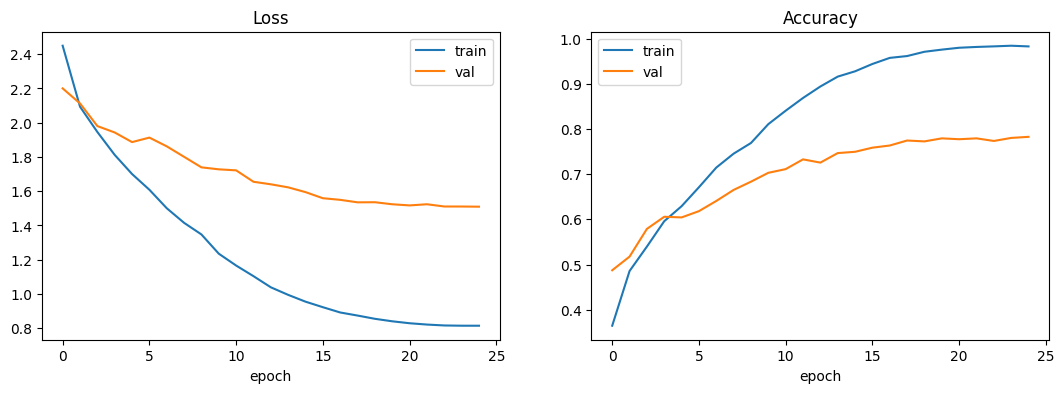

In [14]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(history['train_loss'], label='train')
ax1.plot(history['val_loss'], label='val')
ax1.set_title('Loss'); ax1.set_xlabel('epoch'); ax1.legend()
ax2.plot(history['train_acc'], label='train')
ax2.plot(history['val_acc'], label='val')
ax2.set_title('Accuracy'); ax2.set_xlabel('epoch'); ax2.legend()
plt.show()

## 6. Evaluate on the test split
Reloads the best checkpoint (highest val accuracy) before evaluating.

In [15]:
from pathlib import Path
from src.training import classification_metrics, plot_confusion_matrix

trainer.load_checkpoint(Path(cfg.output.checkpoint_dir) / 'best.pth')
y_true, y_pred = trainer.predict(dm.test_dataloader())

metrics = classification_metrics(y_true, y_pred, dm.class_names)
print(f"Test accuracy : {metrics['accuracy']:.4f}")
print(f"Macro F1      : {metrics['macro_f1']:.4f}")
print(f"Weighted F1   : {metrics['weighted_f1']:.4f}")
print()
print(metrics['report_text'])

predict:   0%|          | 0/49 [00:00<?, ?it/s]

/content/skin-disease/src/training/trainer.py:174: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=self.use_amp):


Test accuracy : 0.7930
Macro F1      : 0.7671
Weighted F1   : 0.7927

                     precision    recall  f1-score   support

               Acne       0.88      0.88      0.88        65
  Actinic_Keratosis       0.79      0.80      0.79        83
      Benign_tumors       0.80      0.72      0.76       121
            Bullous       0.74      0.73      0.73        55
        Candidiasis       0.63      0.81      0.71        27
       DrugEruption       0.66      0.70      0.68        61
             Eczema       0.78      0.82      0.80       112
 Infestations_Bites       0.69      0.67      0.68        60
             Lichen       0.76      0.72      0.74        61
              Lupus       0.58      0.56      0.57        34
              Moles       0.74      0.72      0.73        40
          Psoriasis       0.76      0.72      0.74        88
            Rosacea       0.78      0.89      0.83        28
  Seborrh_Keratoses       0.86      0.84      0.85        51
         SkinC

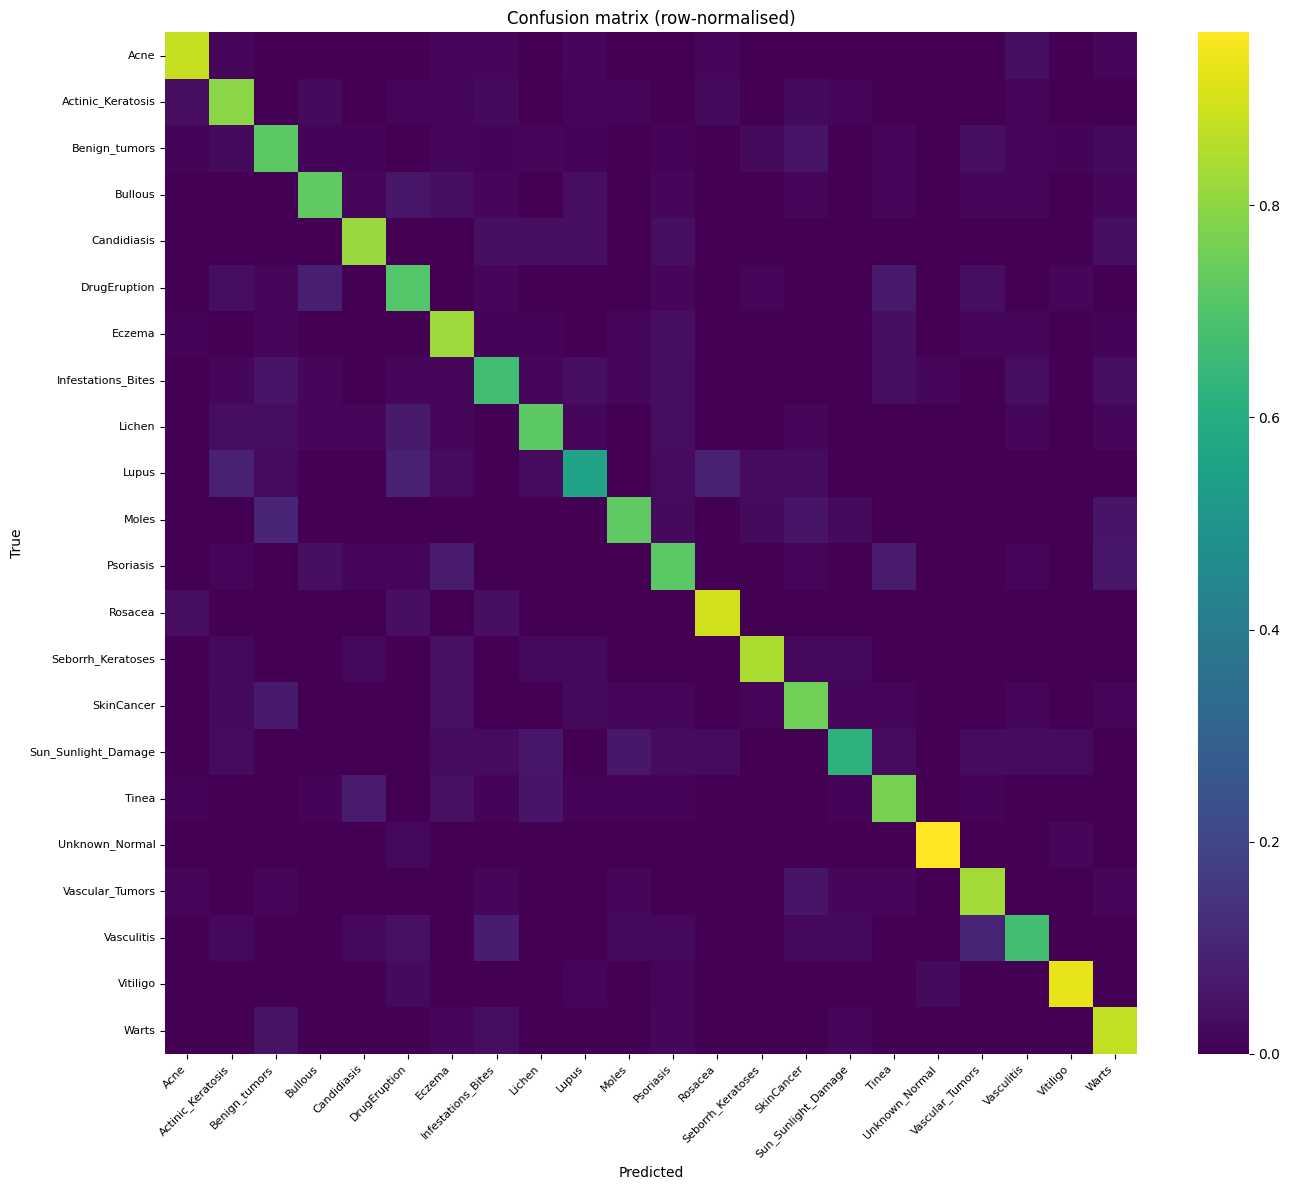

In [16]:
fig = plot_confusion_matrix(
    y_true, y_pred, dm.class_names,
    save_path=Path(cfg.output.log_dir) / 'confusion_matrix.png',
)
plt.show()

## 7. Save the model to Google Drive
Persists the checkpoint so it survives after the Colab session ends.

In [17]:
from google.colab import drive
import shutil, os

drive.mount('/content/drive')
DEST = '/content/drive/MyDrive/skin-disease-model'
os.makedirs(DEST, exist_ok=True)

shutil.copy(Path(cfg.output.checkpoint_dir) / 'best.pth', DEST)
shutil.copy(Path(cfg.output.log_dir) / 'confusion_matrix.png', DEST)
shutil.copy(Path(cfg.output.log_dir) / 'history.json', DEST)
print('Saved to', DEST)
print(os.listdir(DEST))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved to /content/drive/MyDrive/skin-disease-model
['best.pth', 'confusion_matrix.png', 'history.json']


## 8. (Optional) Single-image prediction

In [18]:
from src.inference import SkinDiseasePredictor

predictor = SkinDiseasePredictor(Path(cfg.output.checkpoint_dir) / 'best.pth')
from google.colab import files
up = files.upload()
img_path = list(up.keys())[0]
for r in predictor.predict(img_path, top_k=5):
    print(f"{r['label']:<25} {r['probability']:.3f}")

IndexError: list index out of range